Step 1:Import Libraries & Set Configuration

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Configuration
STOCK_SYMBOL = "AAPL"
START_DATE = "2015-01-01"
END_DATE = "2025-05-30"
SEQUENCE_LENGTH = 60         # Use last 60 days to predict next day
PREDICTION_DAYS = 30         # Predict next 30 days
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

Step 2:Download Stock Data

In [2]:
data = yf.download(STOCK_SYMBOL, start=START_DATE, end=END_DATE)
df = data[['Close']].copy()   # We only use Closing Price
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Price            Close
Ticker            AAPL
Date                  
2025-05-22  200.564331
2025-05-23  194.498383
2025-05-27  199.418869
2025-05-28  199.628036
2025-05-29  199.159882


Step 3:Scale the Data

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

Step 4:Create Sequences

In [4]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])      # Past 60 days
        y.append(data[i + seq_length])        # Next day's price
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQUENCE_LENGTH)

Step 5:Split into Train & Test

In [5]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

Step 6:Convert to PyTorch Tensors & Create DataLoader

In [6]:
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

# Custom Dataset
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

Step 7:Define the LSTM Model

In [7]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 64).to(x.device)
        c0 = torch.zeros(2, x.size(0), 64).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])   # Take output from last time step
        return out

model = LSTMModel()

Step 8:Train the Model

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.6f}')

Epoch 10/50, Loss: 0.000240
Epoch 20/50, Loss: 0.000199
Epoch 30/50, Loss: 0.000164
Epoch 40/50, Loss: 0.000138
Epoch 50/50, Loss: 0.000115


Step 9:Test & Plot Results

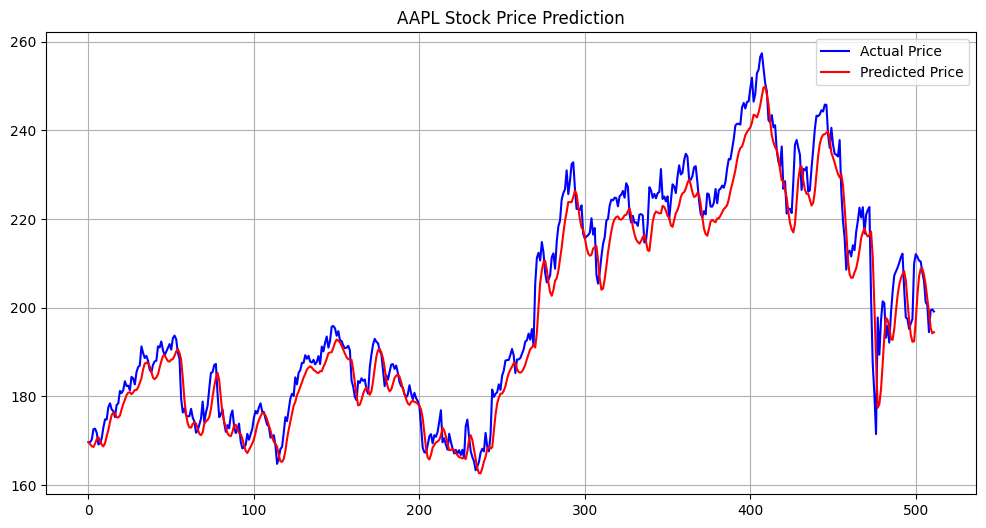

In [9]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test.to(device)).cpu().numpy()

test_pred = scaler.inverse_transform(test_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(test_pred, label='Predicted Price', color='red')
plt.title(f'{STOCK_SYMBOL} Stock Price Prediction')
plt.legend()
plt.grid(True)
plt.show()

Step 10:Predict Future Prices (Next 30 Days)

In [10]:
last_sequence = scaled_data[-SEQUENCE_LENGTH:].reshape(1, SEQUENCE_LENGTH, 1)
future_predictions = []

with torch.no_grad():
    for _ in range(PREDICTION_DAYS):
        next_pred = model(torch.FloatTensor(last_sequence).to(device))
        future_predictions.append(next_pred.item())

        # Update sequence with new prediction
        last_sequence = np.append(last_sequence[:, 1:, :],
                                next_pred.cpu().numpy().reshape(1, 1, 1), axis=1)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

print("\nFuture Predictions:")
for i, price in enumerate(future_predictions.flatten(), 1):
    print(f"Day {i}: ${price:.2f}")


Future Predictions:
Day 1: $195.20
Day 2: $194.62
Day 3: $193.47
Day 4: $192.10
Day 5: $190.69
Day 6: $189.28
Day 7: $187.91
Day 8: $186.57
Day 9: $185.27
Day 10: $184.02
Day 11: $182.81
Day 12: $181.65
Day 13: $180.52
Day 14: $179.43
Day 15: $178.38
Day 16: $177.37
Day 17: $176.39
Day 18: $175.45
Day 19: $174.53
Day 20: $173.65
Day 21: $172.80
Day 22: $171.97
Day 23: $171.17
Day 24: $170.39
Day 25: $169.64
Day 26: $168.91
Day 27: $168.21
Day 28: $167.52
Day 29: $166.85
Day 30: $166.21
